In [16]:
import sys
from tqdm import tqdm

import torch
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

from src.processor import Processor
from main import init_parser, update_parameters

In [17]:
from IPython.display import HTML
import matplotlib.animation as animation

plt.rcParams["animation.embed_limit"] = 100  # MB

# Note
You can use this to view *aligned* and *unaligned* skeletons. 

In [ ]:
# alignment = 'unaligned'
alignment = 'aligned'

class_idx = 37 # 26

In [19]:
parser = init_parser()
sys.argv = ['notebook_cell', '--config', './config/ntu60/ntu60_resume.yaml']
args = parser.parse_args()
args = update_parameters(parser, args)  # cmd > yaml > default

In [20]:
p = Processor(args)

[ 2026-01-18 17:08:23,875 ] Saving folder path: ./workdir/ntu_smv/config/ntu60/ntu60_resume/2026-01-18 17-08-23
[ 2026-01-18 17:08:23,875 ] 
[ 2026-01-18 17:08:23,878 ] Saving model name: Trans-GCN_ntu60
[ 2026-01-18 17:08:39,932 ] Dataset: ntu60
[ 2026-01-18 17:08:39,935 ] Batch size: train-64, eval-128
[ 2026-01-18 17:08:39,937 ] Data shape (branch, channel, frame, joint, person): [1, 3, 64, 25, 2]
[ 2026-01-18 17:08:39,938 ] Number of action classes: 60
[ 2026-01-18 17:08:40,005 ] Model: Trans-GCN {'use_att': True, 'kernel_size': [3, 2], 'dilations': [2, 3], 'reduct_ratio': 2, 'use_gcn': False, 'so2_arg': {'heads': 4, 'angle_partitions': 20, 'rot_one_axis': False}}
[ 2026-01-18 17:08:41,746 ] Model profile: 0.49G FLOPs and 1.06M Parameters
[ 2026-01-18 17:08:41,826 ] Optimizer: SGD {'lr': 0.1, 'momentum': 0.9, 'nesterov': True, 'weight_decay': 0.0002}
[ 2026-01-18 17:08:41,827 ] LR_Scheduler: step {'max_epoch': 100, 'warm_up': 0, 'step_lr': [80, 90]}
[ 2026-01-18 17:08:41,828 ] Loss

In [21]:
def ntu60_label_to_name(label: int) -> str:
    """
    Returns the NTU RGB+D 60 action name for a given label (0-59).

    Args:
        label (int): Action label in [0, 59]

    Returns:
        str: Action class name
    """
    ntu60_classes = [
        "drink water", #0
        "eat meal/snack", #1
        "brushing teeth", #2
        "brushing hair", #3
        "drop", #4
        "pickup", #5
        "throw", #6
        "sitting down", #7
        "standing up (from sitting position)", #8
        "clapping", #9
        "reading", #10
        "writing", #11
        "tear up paper", #12
        "wear jacket", #13
        "take off jacket", #14
        "wear a shoe", #15
        "take off a shoe", #16
        "wear on glasses", #17
        "take off glasses", #18
        "put on a hat/cap", #19
        "take off a hat/cap", #20
        "cheer up", #21
        "hand waving", #22
        "kicking something", #23
        "reach into pocket", #24
        "hopping (one foot jumping)", #25
        "jump up", #26
        "make a phone call/answer phone", #27
        "playing with phone/tablet", #28
        "typing on a keyboard", #29
        "pointing to something with finger", #30
        "taking a selfie", #31
        "check time (from watch)", #32
        "rub two hands together", #33
        "nod head/bow", #34
        "shake head", #35
        "wipe face", #36
        "salute", #37
        "put palms together", #38
        "cross hands in front (say stop)", #39
        "sneeze/cough", #40
        "staggering", #41
        "falling", #42
        "touch head (headache)", #43
        "touch chest (stomachache/heart pain)", #44
        "touch back (backache)", #45
        "touch neck (neckache)", #46
        "nausea or vomiting condition", #47
        "use a fan (with hand or paper)/feeling warm", #48
        "punching/slapping other person", #49
        "kicking other person", #50
        "pushing other person", #51
        "pat on back of other person", #52
        "point finger at the other person", #53
        "hugging other person", #54
        "giving something to other person", #55
        "touch other person's pocket", #56
        "handshaking", #57
        "walking towards each other", #58
        "walking apart from each other" #59
    ]

    if not (0 <= label < 60):
        raise ValueError("Label must be in the range [0, 59].")

    return ntu60_classes[label]


In [22]:
# (source, target) joint connections based on NTU-RGB+D skeleton structure
NTU_CONNECTIONS = [
    (1, 2), (2, 21), (3, 21), (4, 3), (5, 21),
    (6, 5), (7, 6), (8, 7), (9, 21), (10, 9),
    (11, 10), (12, 11), (13, 1), (14, 13), (15, 14),
    (16, 15), (17, 1), (18, 17), (19, 18), (20, 19),
    (22, 23), (23, 8), (24, 25), (25, 12)
]

NTU_CONNECTIONS = [(i-1, j-1) for i,j in NTU_CONNECTIONS]

In [23]:
def animate_ntu_skeleton(
    X,
    act_class_name,
    connections,
    interval=40,
    axis_limit=None
):
    """
    Animate NTU RGB+D skeleton sequence using matplotlib FuncAnimation.

    Parameters
    ----------
    X : Tensor or ndarray
        Shape (T, M, N, 3)
    connections : list of tuple
        Edge list (0-based indices)
    interval : int
        Delay between frames in ms
    axis_limit : float or None
        Fixed axis limit (symmetric). If None, auto-computed.
    """

    # ---- Convert input to numpy ----
    if isinstance(X, torch.Tensor):
        X = X.detach().cpu().numpy()

    T, M, N, C = X.shape
    assert M == 1, "This version supports M=1 only"
    X = X[:, 0]  # (T, N, 3)

    # ---- Create figure and 3D axis ----
    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111, projection="3d")

    # ---- Set axis limits once (important!) ----
    if axis_limit is None:
        mins = X.min(axis=(0, 1))
        maxs = X.max(axis=(0, 1))
        center = (mins + maxs) / 2
        radius = np.max(maxs - mins) / 2
        ax.set_xlim(center[0] - radius, center[0] + radius)
        ax.set_ylim(center[1] - radius, center[1] + radius)
        ax.set_zlim(center[2] - radius, center[2] + radius)
    else:
        ax.set_xlim(-axis_limit, axis_limit)
        ax.set_ylim(-axis_limit, axis_limit)
        ax.set_zlim(-axis_limit, axis_limit)

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.grid(True)

    # ---- Create persistent artists ----

    # Joints (scatter)
    joints = X[0]
    joints_plot = ax.scatter(
        joints[:, 0],
        joints[:, 1],
        joints[:, 2],
        c="r",
        s=30
    )

    # Bones (lines)
    bone_lines = []
    for i, j in connections:
        line, = ax.plot(
            [joints[i, 0], joints[j, 0]],
            [joints[i, 1], joints[j, 1]],
            [joints[i, 2], joints[j, 2]],
            c="b",
            linewidth=2
        )
        bone_lines.append(line)

    # ---- Update function (THIS is the key) ----
    def update(frame):
        joints = X[frame]

        # update joint positions
        joints_plot._offsets3d = (
            joints[:, 0],
            joints[:, 1],
            joints[:, 2]
        )

        # update bones
        for line, (i, j) in zip(bone_lines, connections):
            line.set_data(
                [joints[i, 0], joints[j, 0]],
                [joints[i, 1], joints[j, 1]]
            )
            line.set_3d_properties(
                [joints[i, 2], joints[j, 2]]
            )

        ax.set_title(f"{act_class_name}")

        return [joints_plot] + bone_lines

    # ---- Create animation ----
    ani = FuncAnimation(
        fig,
        update,
        frames=T,
        interval=interval,
        blit=False
    )

    plt.show()
    return ani


In [24]:
def get_sample(seed=None, class_idx=None, split='train'):
    
    if seed is not None:
        np.random.seed(seed)
    
    num = np.random.randint(low=0, high=234)

    loader = p.train_loader if split=='train' else p.eval_loader
    iter = tqdm(loader, dynamic_ncols=True)
    for i, (x, y) in enumerate(iter):
        # Using GPU
        x = x[0][0].float() # shape: C, T, V, M
        x = x.permute(1,3,2,0) # shape: T, M, V, C
        y = y[0].item()
        class_name = ntu60_label_to_name(y) # class name

        if class_idx is not None:
            if y == class_idx:
                break
        elif i == num:
            break # we just need one sample

    return x, class_name

In [25]:
split='test'
x, y = get_sample(class_idx=class_idx, split=split)
print(f"class: {y}")

 18%|█▊        | 27/148 [00:00<00:03, 35.13it/s]

class: salute


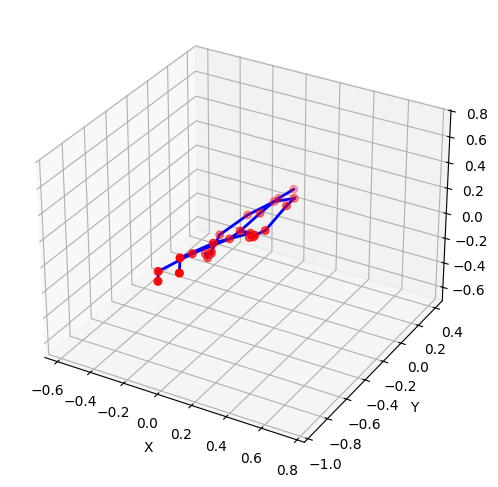

[ 2026-01-18 17:08:42,989 ] Animation.save using <class 'matplotlib.animation.PillowWriter'>


In [26]:
X = x[:,0].unsqueeze(1) # shape: T, 1, V, C
ani = animate_ntu_skeleton(
    X,
    act_class_name=y,
    connections=NTU_CONNECTIONS,
    interval=40,
    # axis_limit=1.0
)

ani.save(
    f"ntu_skeleton-{y}--{split}--{alignment}.gif",
    writer="pillow",
    fps=25
)

In [27]:
HTML(ani.to_jshtml())

[ 2026-01-18 17:08:46,958 ] Animation.save using <class 'matplotlib.animation.HTMLWriter'>


In [28]:
split='train'
x, y = get_sample(class_idx=class_idx, split=split)
print(f"class: {y}")

  7%|▋         | 41/588 [00:00<00:08, 67.35it/s]

class: salute


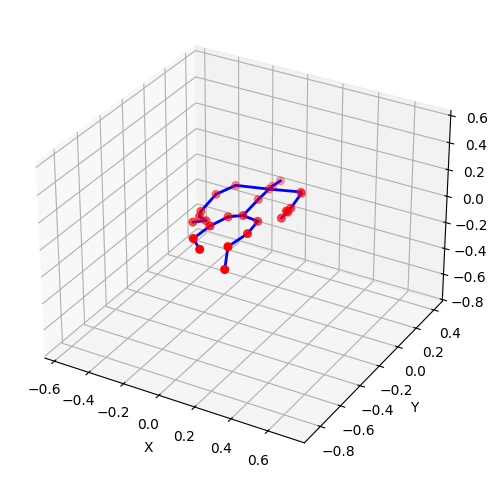

[ 2026-01-18 17:08:51,357 ] Animation.save using <class 'matplotlib.animation.PillowWriter'>


In [29]:
X = x[:,0].unsqueeze(1) # shape: T, 1, V, C
ani = animate_ntu_skeleton(
    X,
    act_class_name=y,
    connections=NTU_CONNECTIONS,
    interval=40,
    # axis_limit=1.0
)

ani.save(
    f"ntu_skeleton-{y}--{split}--{alignment}.gif",
    writer="pillow",
    fps=25
)

In [30]:
HTML(ani.to_jshtml())

[ 2026-01-18 17:08:55,246 ] Animation.save using <class 'matplotlib.animation.HTMLWriter'>
